In [86]:
import pandas as pd
import matplotlib.pyplot as plt

In [87]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Proses memahami data

In [88]:
# mencari jumlah baris data dan kolom
df.shape

(9994, 21)

In [89]:
# mencari tahu tipe data tiap kolom dan jumlah data kosong (null)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [90]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

dataset ini tidak memiliki missing value

In [91]:
# menampilkan ringkasan statistik
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [92]:
# cek apakah ada data yang berulang
df.duplicated().sum()

np.int64(0)

## Data cleaning

In [93]:
# ubah tipe data tanggal (sebelumnya masih bertipe data object)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [94]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

## Exploratory data analysis

In [95]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [96]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [97]:
numeric_columns = df.select_dtypes(include='number').columns
numeric_columns

Index(['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit'], dtype='object')

In [98]:
numeric_columns = numeric_columns.drop(['Row ID', 'Postal Code']) # hapus data yang tidak perlu

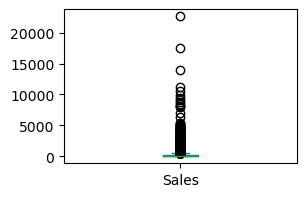

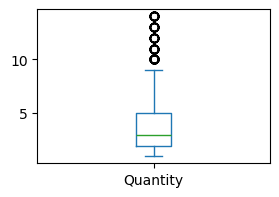

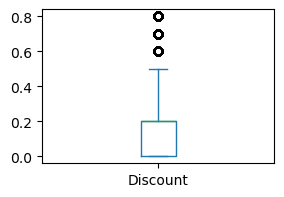

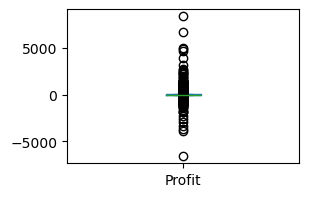

In [99]:
# proses membuat box plot untuk melihat apakah ada outlier
for x in numeric_columns:
    df[x].plot(kind='box', figsize=(3, 2))
    plt.show()

keempat data numerik memiliki outlier, namun kali ini dibiarkan karena data hanya digunakan untuk visualisasi dan mencari insight

### A. Gambaran umum bisnis

- Berapa total Sales dan Profit dalam seluruh dataset?
- Bagaimana distribusi Sales dan Profit per transaksi?
- Berapa rata-rata Sales, Profit, dan Quantity per transaksi/order?

In [100]:
# total sales
df['Sales'].sum()

np.float64(2297200.8603000003)

In [101]:
# total profit
df['Profit'].sum()

np.float64(286397.0217)

<Axes: title={'center': 'Sales Distribution'}, xlabel='Sales', ylabel='Frequency'>

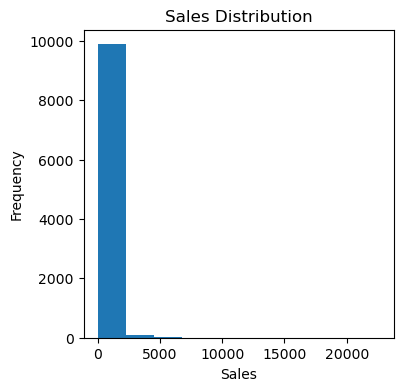

In [102]:
# distribusi sales
df['Sales'].plot(kind='hist', ylabel='Frequency', xlabel='Sales', figsize=(4,4), title='Sales Distribution')

Berdasarkan histogram tersebut, dapat diketahui bahwa sebagian besar Sales terkonsentrasi pada rentang angka 0 hingga sekitar 2000. Selain itu, terlihat juga terdapat sebagian kecil Sales yang memiliki nilai yang sangat tinggi (sesuai dengan pengecekan outlier), dimana nilainya bisa mencapai lebih dari 20000.

<Axes: title={'center': 'Sales Distribution (< 2000)'}, xlabel='Sales', ylabel='Frequency'>

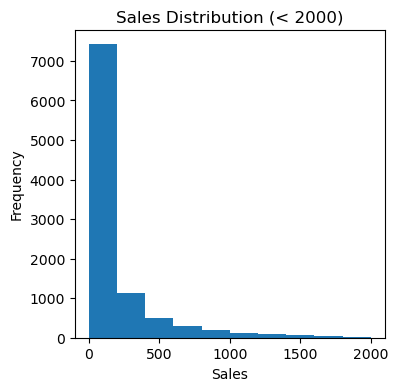

In [103]:
df[df['Sales'] < 2000]['Sales'].plot(kind='hist', ylabel='Frequency', 
                                     xlabel='Sales', figsize=(4,4), title='Sales Distribution (< 2000)')

Pada histogram yang difokuskan ke nilai Sales di bawah 2000, terlihat lebih jelas bahwa Sales yang bernilai pada rentang 0-200 mendominasi total dengan lebih dari 7000 data. Setelah itu, frekuensi menurun tajam secara konsisten pada Sales dengan nilai yang lebih tinggi. Bentuk distribusi ini right skewed.

<Axes: title={'center': 'Profit Distribution'}, xlabel='Profit', ylabel='Frequency'>

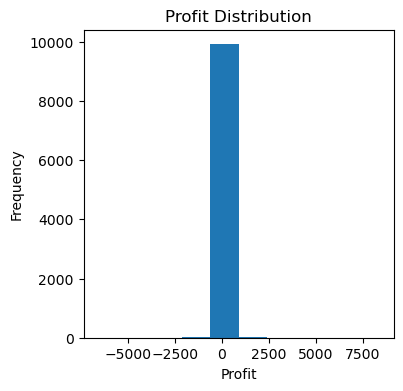

In [104]:
# distribusi profit
df['Profit'].plot(kind='hist', ylabel='Frequency', xlabel='Profit', figsize=(4,4), title='Profit Distribution')

Pada histogram tersebut, terlihat bahwa data Profit terkonsentrasi pada rentang nilai di sekitar -1000 hingga 1000 (berjumlah hampir 10000 data). Terdapat juga sebagian kecil data Profit yang ada di luar rentang tersebut (terindikasi sebagai outlier).

<Axes: title={'center': 'Profit Distribution (range -1000 to 1000)'}, xlabel='Profit', ylabel='Frequency'>

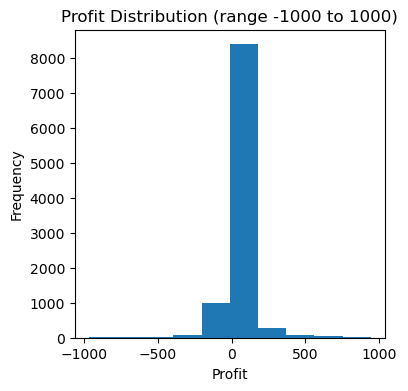

In [105]:
df[(df['Profit'] < 1000) & (df['Profit'] > -1000)]['Profit'].plot(kind='hist', ylabel='Frequency', 
                                                                  xlabel='Profit', figsize=(4,4), 
                                                                  title='Profit Distribution (range -1000 to 1000)')

Mayoritas data terkonsentrasi pada rentang profit 0 hingga 150, dengan jumlah lebih dari 8000 data. Sekitar 1000 data berada pada rentang Profit -200 hingga 0.

In [106]:
# Rata-rata Sales, Profit, dan Quantity per transaksi
df[['Sales', 'Profit', 'Quantity']].mean()

Sales       229.858001
Profit       28.656896
Quantity      3.789574
dtype: float64

### B. Analisis waktu

- Bagaimana perkembangan Sales dari tahun ke tahun?
- Bagaimana perkembangan Profit dari tahun ke tahun?
- Bulan apa yang memiliki Sales tertinggi dan terendah?
- Apakah terdapat pola tertentu pada Sales berdasarkan bulan?

In [107]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [108]:
# Perkembangan sales dari tahun ke tahun
idx1 = df['Order Date'].dt.year
idx1

0       2016
1       2016
2       2016
3       2015
4       2015
        ... 
9989    2014
9990    2017
9991    2017
9992    2017
9993    2017
Name: Order Date, Length: 9994, dtype: int32

In [109]:
idx1.unique()

array([2016, 2015, 2014, 2017], dtype=int32)

In [110]:
df_sales_year = df.pivot_table(index=idx1, values='Sales', aggfunc='mean')

In [111]:
df_sales_year

,Sales
Order Date,
2014,242.974159
2015,223.849909
2016,235.487282
2017,221.381418


<Axes: title={'center': 'Yearly Average Sales'}, xlabel='Year', ylabel='Sales'>

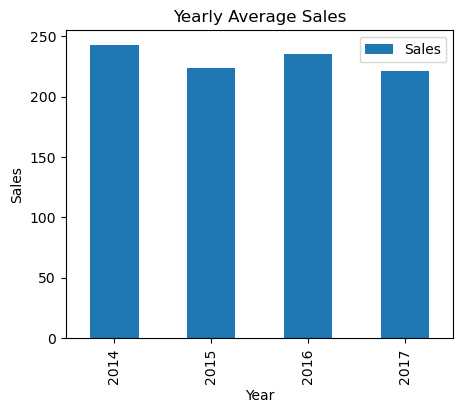

In [112]:
df_sales_year.plot(kind='bar', xlabel='Year', ylabel='Sales', title='Yearly Average Sales', figsize=(5,4))

Bar plot tersebut menunjukkan nilai Sales rata rata setiap tahun. Dapat dilihat bahwa toko mencatat Sales tertinggi pada tahun 2014, dan Sales terendah pada tahun 2017. 

In [113]:
# Perkembangan profit dari tahun ke tahun
df_profit_year = df.pivot_table(index=idx1, values='Profit', aggfunc='mean')
df_profit_year

,Profit
Order Date,
2014,24.858994
2015,29.314274
2016,31.617771
2017,28.212340


<Axes: title={'center': 'Yearly Average Profit'}, xlabel='Year', ylabel='Profit'>

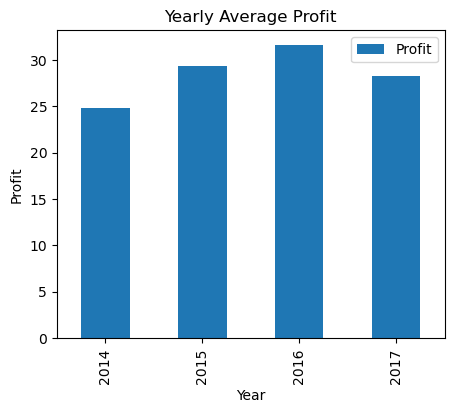

In [114]:
df_profit_year.plot(kind='bar', xlabel='Year', ylabel='Profit', title='Yearly Average Profit', figsize=(5,4))

Bar plot tersebut menunjukkan nilai Profit rata rata setiap tahun. Dapat dilihat bahwa toko mendapat keuntungan tertinggi pada tahun 2016, dan keuntungan terendah pada tahun 2014. 

In [115]:
# Perkembangan sales berdasarkan bulan
idx2 = df['Order Date'].dt.month
idx2

0       11
1       11
2        6
3       10
4       10
        ..
9989     1
9990     2
9991     2
9992     2
9993     5
Name: Order Date, Length: 9994, dtype: int32

In [116]:
df_sales_month = df.pivot_table(index=idx2, values='Sales', aggfunc='mean')
df_sales_month

,Sales
Order Date,
1,249.146550
2,199.170838
3,294.548116
4,206.230731
5,210.923553
6,212.996763
7,207.377601
8,225.274877
9,222.451154


<Axes: title={'center': 'Monthly Average Sales'}, xlabel='Month', ylabel='Sales'>

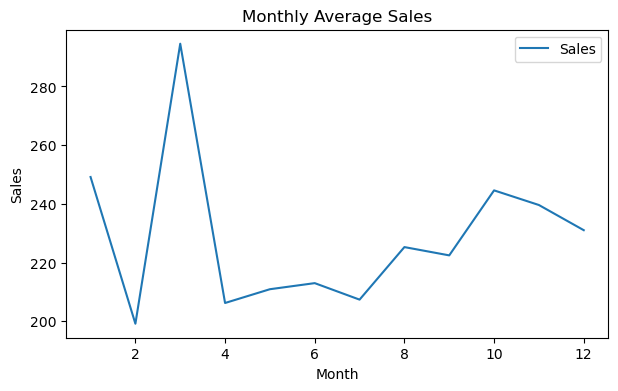

In [117]:
df_sales_month.plot(kind='line', xlabel='Month', ylabel='Sales', title='Monthly Average Sales', figsize=(7,4))

Berdasarkan line plot tersebut, terlihat bahwa Sales mengalami kenaikan yang sangat besar pada bulan Maret. Pada bulan tersebut, Sales berada pada nilai tertinggi yaitu sekitar 294. Sales terendah terjadi pada bulan Februari yang hanya berkisar di angka 199.

Tidak ada pola jelas yang dapat ditemukan dari rata rata sales bulanan tersebut. 

### C. Analisis produk

- Kategori produk mana yang menghasilkan Sales terbesar?
- Kategori produk mana yang menghasilkan Profit terbesar?
- Apa 10 produk dengan Sales terbesar?
- Apa 10 produk dengan Profit terbesar?
- Apakah produk dengan Sales tinggi juga menghasilkan Profit tinggi?

In [118]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [119]:
# Mencari kategori yang menghasilkan sales paling tinggi
df_category_sales = df.pivot_table(index='Category', values='Sales', aggfunc='mean')
df_category_sales

,Sales
Category,
Furniture,349.834887
Office Supplies,119.324101
Technology,452.709276


Kategori teknologi memiliki sales paling besar di toko ini.

In [120]:
# Mencari kategori yang menghasilkan profit paling tinggi
df_category_profit = df.pivot_table(index='Category', values='Profit', aggfunc='mean')
df_category_profit

,Profit
Category,
Furniture,8.699327
Office Supplies,20.327050
Technology,78.752002


Kategori teknologi menghasilkan profit paling tinggi di toko ini

In [121]:
# 10 produk dengan sales terbesar
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [122]:
# alternatif
df.pivot_table(index='Product Name', values='Sales', aggfunc='sum').sort_values(by='Sales', ascending=False).head(10)

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [123]:
# 10 produk dengan profit tertinggi
df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

In [124]:
# Menghitung korelasi antara Sales dengan Profit
product_summary = df.groupby('Product Name')[['Sales', 'Profit']].sum()
product_summary

,Sales,Profit
Product Name,,
"""While you Were Out"" Message Book, One Form per Page",25.228,10.3880
"#10 Gummed Flap White Envelopes, 100/Box",41.300,16.7678
#10 Self-Seal White Envelopes,108.682,52.1230
"#10 White Business Envelopes,4 1/8 x 9 1/2",488.904,223.1408
"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,115.2806
...,...,...
"iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",477.660,115.6440
iOttie HLCRIO102 Car Mount,215.892,-11.9940
iOttie XL Car Mount,223.888,-50.3748


In [125]:
correlation = product_summary['Sales'].corr(product_summary['Profit'])
print(f"Korelasi Sales dengan Profit: {correlation:.2f}")

Korelasi Sales dengan Profit: 0.59


In [126]:
df.corr(numeric_only=True)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


Korelasi Sales dengan Profit pada level transaksi (data mentah) sebesar 0.48, sedangkan pada level produk (setelah agregasi) sebesar 0.59. Perbedaan ini terjadi karena proses agregasi mengurangi variasi/noise antar transaksi individual.

Berdasarkan kedua hasil korelasi tersebut, dapat disimpulkan bahwa Profit dan Sales memiliki hubungan yang sedang. Ini berarti produk dengan Sales tinggi cenderung memiliki Profit yang tinggi, namun tidak selalu.

### D. Analisis lokasi

- Region mana yang menghasilkan Sales terbesar?
- State mana yang memiliki Profit terbesar?
- Apakah ada State dengan Sales tinggi tetapi Profit negatif?

In [127]:
# Mencari region dengan Sales terbesar
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

Region yang menghasilkan Sales terbesar adalah region West.

In [128]:
# State yang menghasilkan Profit terbesar
df.pivot_table(index='State', values='Profit', aggfunc='sum').sort_values(by='Profit', ascending=False).head(5)

,Profit
State,
California,76381.3871
New York,74038.5486
Washington,33402.6517
Michigan,24463.1876
Virginia,18597.9504


California adalah state yang menghasilkan Profit terbesar

In [129]:
# Mencari State dengan Sales tinggi tetapi Profit negatif
df_negative_profit = df.groupby('State')[['Profit', 'Sales']].sum()
df_negative_profit = df_negative_profit[df_negative_profit['Profit'] < 0].sort_values(by='Sales', ascending=False).head(5)
df_negative_profit

,Profit,Sales
State,,
Texas,-25729.3563,170188.0458
Pennsylvania,-15559.9603,116511.9140
Florida,-3399.3017,89473.7080
Illinois,-12607.8870,80166.1010
Ohio,-16971.3766,78258.1360


In [130]:
# cari State dengan Sales tinggi
df_top_sales = df.pivot_table(index='State', values='Sales', aggfunc='sum').sort_values(by='Sales', ascending=False).head(5)
df_top_sales

,Sales
State,
California,457687.6315
New York,310876.2710
Texas,170188.0458
Washington,138641.2700
Pennsylvania,116511.9140


In [131]:
pd.merge(df_negative_profit, df_top_sales, on=['State', 'Sales'], how='inner')

,Profit,Sales
State,,
Texas,-25729.3563,170188.0458
Pennsylvania,-15559.9603,116511.9140


Texas dan Pennsylvania termasuk dalam daftar 5 State dengan jumlah Sales tertinggi, namun memiliki Profit negatif.

### E. Analisis Customer

- Segment customer mana yang menghasilkan Profit terbesar?
- Siapa 10 customer dengan total Sales terbesar?
- Apakah customer dengan Sales tinggi juga memiliki Profit tinggi?

In [132]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [133]:
# Segment customer yang menghasilkan profit paling besar
df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

Segment Consumer menghasilkan profit paling besar.

In [134]:
# Mencari 10 customer dengan Sales terbesar
df.pivot_table(index='Customer Name', values='Sales', aggfunc='sum').sort_values(by='Sales', ascending=False).head(10)

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


In [135]:
# Apakah customer dengan Sales tinggi juga memiliki Profit tinggi
sales_profit_corr = df.groupby('Customer Name')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)
sales_profit_corr

,Sales,Profit
Customer Name,,
Sean Miller,25043.050,-1980.7393
Tamara Chand,19052.218,8981.3239
Raymond Buch,15117.339,6976.0959
Tom Ashbrook,14595.620,4703.7883
Adrian Barton,14473.571,5444.8055
...,...,...
Roy Skaria,22.328,9.5838
Mitch Gastineau,16.739,-1.2453
Carl Jackson,16.520,1.6520


In [136]:
sales_profit_cor = sales_profit_corr['Sales'].corr(sales_profit_corr['Profit'])
sales_profit_cor

np.float64(0.5063511134292414)

Korelasi Sales dengan Profit pada customer bernilai di sekitar 0.5, yang mana hal ini berarti Sales dan Profit memiliki hubungan tingkat menengah. Customer dengan Sales tinggi cenderung memiliki Profit yang tinggi juga, meskipun tidak selalu.

### F. Analisis discount dan profit

- Bagaimana rata-rata Profit berdasarkan Discount?
- Apakah Discount yang lebih besar berkaitan dengan Profit yang lebih rendah?
- Kategori produk mana yang paling banyak memberikan Discount?
- Apakah kategori dengan Sales terbesar juga memiliki Profit Margin yang besar?

In [137]:
df['Discount'].unique()

array([0.  , 0.45, 0.2 , 0.8 , 0.3 , 0.5 , 0.7 , 0.6 , 0.32, 0.1 , 0.4 ,
       0.15])

In [138]:
# Mencari rata rata Profit berdasarkan Discount
df_discount_profit = df.pivot_table(index='Discount', values='Profit', aggfunc='mean')
df_discount_profit

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.679636
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


In [139]:
df_display = df_discount_profit.copy()
df_display.index = (df_display.index * 100).round(1).astype(str) + '%'
df_display

,Profit
Discount,
0.0%,66.900292
10.0%,96.055074
15.0%,27.288298
20.0%,24.702572
30.0%,-45.679636
32.0%,-88.560656
40.0%,-111.927429
45.0%,-226.646464
50.0%,-310.703456


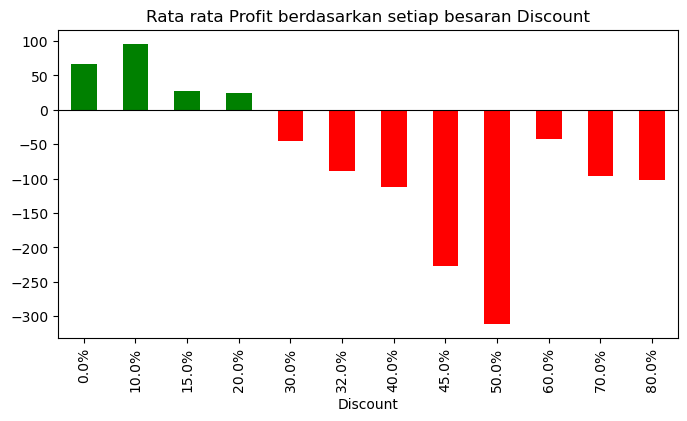

In [140]:
import matplotlib.pyplot as plt

colors = ['red' if x < 0 else 'green' for x in df_display['Profit']]

ax = df_display['Profit'].plot(kind='bar', color=colors, title='Rata rata Profit berdasarkan setiap besaran Discount',figsize=(8,4))
ax.axhline(0, color='black', linewidth=0.8)

Profit bernilai positif (>0) ketika Discount 20% atau lebih rendah. Sebaliknya, ketika Discount lebih dari 20%, Profit akan bernilai negatif. Rata rata kerugian terbesar terjadi pada Discount 50%.

In [141]:
# Mencari korelasi Discount dengan rata rata Profit
df_dp_corr = df_discount_profit.reset_index()
df_dp_corr

,Discount,Profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


In [142]:
df_dp_corr = df_dp_corr['Discount'].corr(df_dp_corr['Profit'])
df_dp_corr

np.float64(-0.6131241722792683)

Korelasi bernilai negatif menunjukkan adanya hubungan yang saling berbalik. Pada kasus ini, korelasi bernilai -0.6 yang berarti Discount dan rata rata Profit memiliki hubungan yang lumayan kuat. Jika Discount tinggi, maka rata rata Profit akan cenderung rendah (tidak selalu), dan begitu juga sebaliknya.

In [143]:
# Kategori produk yang memberikan banyak discount

In [144]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [145]:
df[df['Discount'] > 0].groupby('Category')['Discount'].count().sort_values(ascending=False)

Category
Office Supplies    2897
Furniture          1285
Technology         1014
Name: Discount, dtype: int64

In [146]:
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

Ketgori yang paling banyak memberi Discount adalah kategori Office Supplies

In [147]:
# Mencari profit margin
# Profit Margin = Profit / Sales

In [148]:
df['Profit Margin'] = df['Profit']/df['Sales']
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,0.16
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,0.30
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,0.47


In [149]:
df[['Sales', 'Profit Margin']].sort_values(by='Sales', ascending=False).head(10)

,Sales,Profit Margin
2697,22638.480,-0.080000
6826,17499.950,0.480000
8153,13999.960,0.480000
2623,11199.968,0.350000
4190,10499.970,0.480000
9039,9892.740,0.500000
4098,9449.950,0.490000
4277,9099.930,0.260000
8488,8749.950,0.320000
6425,8399.976,0.133333


In [150]:
df['Profit Margin'].mean()

np.float64(0.12031392972104459)

9 dari 10 produk yang termasuk dalam nilai Sales tertinggi memiliki Profit Margin di atas rata rata.

### G. Visualisasi Tambahan

In [151]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,0.16
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,0.30
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,0.47


In [152]:
df.Region.unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [153]:
# Menggunakan pie chart untuk menampilkan jumlah Profit dari tiap region
df_region_profit = df.groupby('Region')['Profit'].sum()
df_region_profit


Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

<Axes: title={'center': 'Kontribusi tiap Region terhadap jumlah Profit'}>

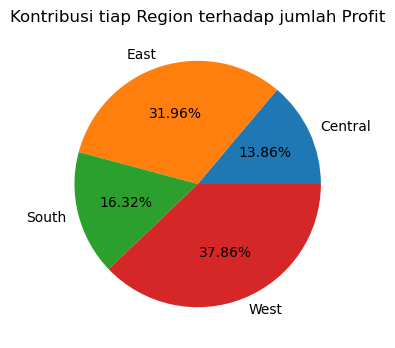

In [154]:
df_region_profit.plot(kind='pie', ylabel='', title='Kontribusi tiap Region terhadap jumlah Profit', autopct='%1.2f%%', figsize=(4,4))

<Axes: title={'center': 'Hubungan Sales dengan Profit'}, xlabel='Profit', ylabel='Sales'>

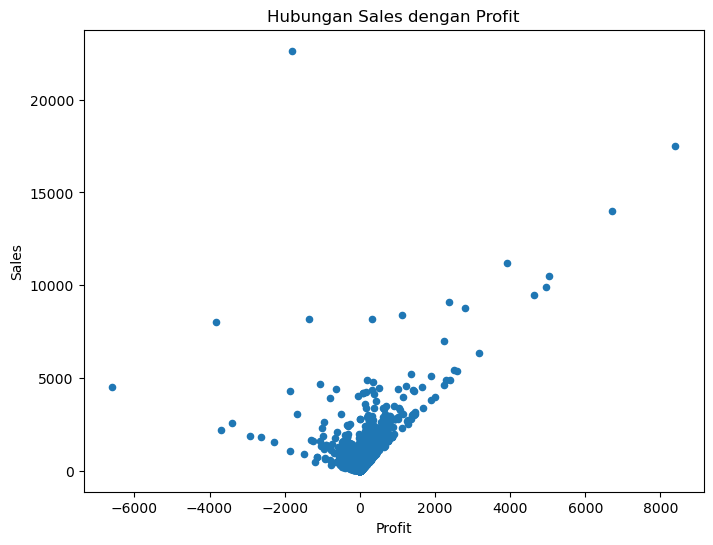

In [155]:
# Melihat hubungan antara Sales dengan Discount menggunakan scatter plot
df.plot(kind='scatter', x='Profit', y='Sales', figsize=(8,6), title='Hubungan Sales dengan Profit')

In [156]:
df['Ship Mode'].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

In [157]:
# Membandingkan rata rata Sales berdasarkan Ship Mode
df_sales_shipmode = df.pivot_table(index='Ship Mode', values='Sales', aggfunc='mean')
df_sales_shipmode

,Sales
Ship Mode,
First Class,228.497024
Same Day,236.396179
Second Class,236.089239
Standard Class,227.583067


<Axes: xlabel='Ship Mode', ylabel='Sales'>

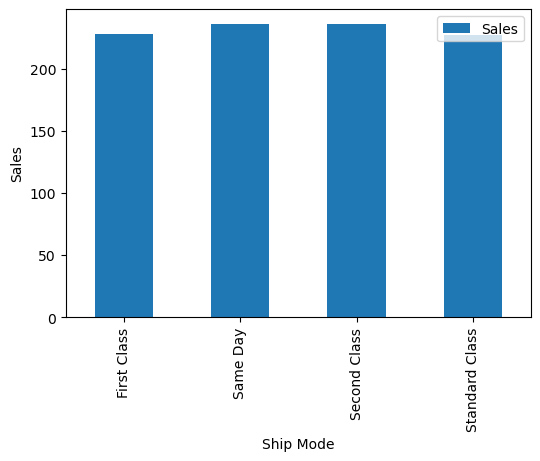

In [158]:
df_sales_shipmode.plot(kind='bar', ylabel='Sales', figsize=(6,4))

## Kesimpulan

Dataset Superstore ini menunjukkan bahwa performa bisnis dipengaruhi oleh beberapa faktor utama: kategori Technology menghasilkan Sales dan Profit rata-rata tertinggi. Sementara itu, pemberian Discount di atas 20% cenderung membuat rata-rata Profit menjadi negatif (korelasi Discount dengan Profit sekitar -0,6), dengan kerugian terbesar terjadi pada Discount 50%. Dari sisi lokasi dan pelanggan, region West mencatat Sales tertinggi dan California adalah state dengan Profit terbesar, namun Texas dan Pennsylvania menjadi contoh di mana keduanya memiliki Sales tinggi namun justru menghasilkan Profit negatif. Hal ini menandakan strategi diskon atau biaya operasional di wilayah tersebut yang perlu dievaluasi.